In [282]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [193]:
df = pd.read_csv('Extended_Stock_Price_Dataset.csv')

In [194]:
df.head(20)

,Date,Open,High,Low,Close,Volume
0,2023-01-02,150.000000,152.000000,149.500000,151.000000,1000000
1,2023-01-03,152.300000,153.500000,151.000000,152.000000,1100000
2,2023-01-04,151.500000,152.000000,150.000000,151.800000,1050000
3,2023-01-05,153.000000,154.500000,152.000000,154.000000,1200000
4,2023-01-06,155.000000,156.000000,154.000000,155.500000,1150000
5,2023-01-09,154.200000,155.000000,153.500000,154.800000,1130000
6,2023-01-10,156.000000,157.500000,155.000000,157.000000,1250000
7,2023-01-11,157.500000,158.000000,156.000000,157.800000,1300000
8,2023-01-12,158.000000,159.500000,157.000000,158.500000,1280000
9,2023-01-13,159.000000,160.000000,158.000000,159.500000,1350000


In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    410 non-null    object 
 1   Open    410 non-null    float64
 2   High    410 non-null    float64
 3   Low     410 non-null    float64
 4   Close   410 non-null    float64
 5   Volume  410 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 19.3+ KB


In [196]:
df['Date'] = pd.to_datetime(df['Date'])

In [197]:
df = df.sort_values(by='Date')

In [198]:
df

,Date,Open,High,Low,Close,Volume
0,2023-01-02,150.000000,152.000000,149.500000,151.000000,1000000
1,2023-01-03,152.300000,153.500000,151.000000,152.000000,1100000
2,2023-01-04,151.500000,152.000000,150.000000,151.800000,1050000
3,2023-01-05,153.000000,154.500000,152.000000,154.000000,1200000
4,2023-01-06,155.000000,156.000000,154.000000,155.500000,1150000
...,...,...,...,...,...,...
405,2024-02-13,180.334032,180.401726,183.278017,181.337925,1446397
406,2024-02-14,180.858933,179.421794,180.662031,180.314253,1433233
407,2024-02-15,179.791203,180.107082,185.009054,181.635780,1405502
408,2024-02-16,178.202980,176.707067,176.059321,176.989789,1397405


In [199]:
# Basic stats
total_records = len(df)
start_date = df['Date'].min()
end_date = df['Date'].max()

print("Range: ", start_date, "to", end_date)

calender_days = pd.date_range(df['Date'].min(), df['Date'].max(), freq='D')
print("Calender days: ", len(calender_days))
print("Trading days: ", total_records)
print("Missing days: ", len(calender_days) - total_records)

Range:  2023-01-02 00:00:00 to 2024-02-17 00:00:00
Calender days:  412
Trading days:  410
Missing days:  2


In [200]:
# Gap check between consecutive records

df['Gap'] = df['Date'].diff().dt.days
print("\nGap counts:\n", df['Gap'].value_counts())


Gap counts:
 Gap
1.0    408
3.0      1
Name: count, dtype: int64


In [201]:
# Weekday analysis
weekday_counts = df['Date'].dt.day_name().value_counts()
print("\nRecords per weekday:\n", weekday_counts)


Records per weekday:
 Date
Monday       59
Tuesday      59
Wednesday    59
Thursday     59
Friday       59
Saturday     58
Sunday       57
Name: count, dtype: int64


In [202]:
# Identify exact missing dates
missing = sorted(set(calender_days.date) - set(df['Date'].dt.date))
print("\nMissing calendar dates:", missing)


Missing calendar dates: [datetime.date(2023, 1, 7), datetime.date(2023, 1, 8)]


In [203]:
# Check if weekends present
weekend_rows = df[df['Date'].dt.dayofweek >= 5]
print("\nWeekend records found:", len(weekend_rows))


Weekend records found: 115


In [204]:
df_trading = df[df['Date'].dt.dayofweek < 5].copy()
print("After removing weekends:", len(df_trading))

After removing weekends: 295


In [205]:
df.head(5)

,Date,Open,High,Low,Close,Volume,Gap
0,2023-01-02,150.0,152.0,149.5,151.0,1000000,NaN
1,2023-01-03,152.3,153.5,151.0,152.0,1100000,1.0
2,2023-01-04,151.5,152.0,150.0,151.8,1050000,1.0
3,2023-01-05,153.0,154.5,152.0,154.0,1200000,1.0
4,2023-01-06,155.0,156.0,154.0,155.5,1150000,1.0


In [206]:
# df['Close'].plot()

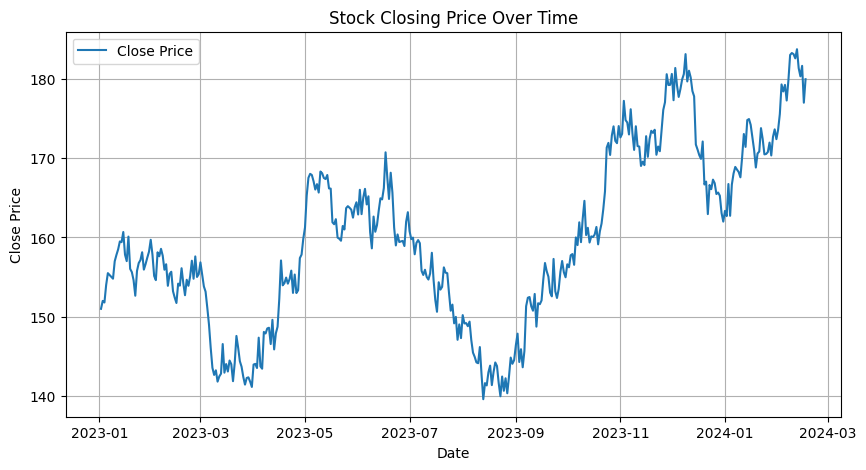

In [207]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'], label="Close Price")
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()


In [208]:
df['NextClose'] = df['Close'].shift(-1)

In [209]:
df.dropna(subset=['NextClose'], inplace=True)

In [210]:
df.tail()

,Date,Open,High,Low,Close,Volume,Gap,NextClose
404,2024-02-12,183.403310,182.185400,185.611327,183.733346,1406519,1.0,181.337925
405,2024-02-13,180.334032,180.401726,183.278017,181.337925,1446397,1.0,180.314253
406,2024-02-14,180.858933,179.421794,180.662031,180.314253,1433233,1.0,181.635780
407,2024-02-15,179.791203,180.107082,185.009054,181.635780,1405502,1.0,176.989789
408,2024-02-16,178.202980,176.707067,176.059321,176.989789,1397405,1.0,179.951904


In [211]:
# Split the data into Features and Target
X = df.drop(columns = ['NextClose', 'Gap', 'Date'], axis = 1)
y = df['NextClose']

In [212]:
X.head()

,Open,High,Low,Close,Volume
0,150.0,152.0,149.5,151.0,1000000
1,152.3,153.5,151.0,152.0,1100000
2,151.5,152.0,150.0,151.8,1050000
3,153.0,154.5,152.0,154.0,1200000
4,155.0,156.0,154.0,155.5,1150000


In [213]:
# shuffle = True
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [214]:
model = LinearRegression()

In [215]:
model.fit(X_train, y_train)

LinearRegression()

In [216]:
y_pred = model.predict(X_test)

In [217]:
y_test

,NextClose
327,180.584346
328,179.217725
329,179.240409
330,180.616133
331,177.304110
...,...
404,181.337925
405,180.314253
406,181.635780
407,176.989789


In [218]:
y_pred

array([177.25421523, 179.02413947, 179.06710178, 179.77813081,
       180.00514325, 179.52631763, 181.79208543, 179.76177467,
       178.40399882, 179.48029013, 180.36085386, 180.47022807,
       180.82271109, 180.62783291, 180.33354879, 179.57036455,
       179.86734108, 176.59450883, 173.19927932, 171.18869095,
       170.27112904, 170.10882013, 169.37242523, 167.4104428 ,
       167.7518321 , 166.22578171, 166.09925626, 165.51029462,
       166.81026652, 166.11918541, 164.76574053, 165.22567317,
       164.41752694, 163.48257293, 163.45992786, 162.92346822,
       163.85002705, 165.99745063, 165.01059665, 165.85044909,
       167.30205421, 168.90101372, 169.63686702, 169.06110414,
       167.44819208, 169.00177084, 171.9695215 , 171.65725199,
       173.69916609, 173.42224264, 173.60224748, 171.50008515,
       171.11353762, 170.55385336, 171.19979352, 170.57185306,
       172.12132167, 172.47668626, 171.22749419, 172.76496884,
       171.31662258, 171.07406243, 171.16972061, 171.68

In [219]:
print("R2 Score:", r2_score(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
print("RMSE:", np.sqrt(mse))

R2 Score: 0.9048469285842251
RMSE: 1.882229522214433


In [220]:
print(model.coef_)

[ 1.97820099e-01 -7.32281072e-01 -8.12697674e-01  2.33986071e+00
  4.37082626e-09]


In [221]:
# Calculate MAPE - Mean Absolute Percentage Error
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE: {:.2f}%".format(mape))

MAPE: 0.84%


In [222]:
# shuffle = False
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
print("RMSE:", np.sqrt(mse))
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)
# Calculate MAPE - Mean Absolute Percentage Error
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE: {:.2f}%".format(mape))

print(model.coef_)


R2 Score: 0.9048469285842251
RMSE: 1.882229522214433
MAE: 1.4598567501405932
MAPE: 0.84%
[ 1.97820099e-01 -7.32281072e-01 -8.12697674e-01  2.33986071e+00
  4.37082626e-09]


With shuffle=True, the model shows R² ≈ 0.97 and MAPE ≈ 0.95% (optimistic, since future information leaks into training). With shuffle=False, R² drops to ≈0.90, but MAPE improves to ≈0.84%, showing that despite the tougher, realistic setup, the model still predicts within 1% error on average.

In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 409 entries, 0 to 408
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       409 non-null    datetime64[ns]
 1   Open       409 non-null    float64       
 2   High       409 non-null    float64       
 3   Low        409 non-null    float64       
 4   Close      409 non-null    float64       
 5   Volume     409 non-null    int64         
 6   Gap        408 non-null    float64       
 7   NextClose  409 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 28.8 KB


## **With Scaling**

In [224]:
df.head()

,Date,Open,High,Low,Close,Volume,Gap,NextClose
0,2023-01-02,150.0,152.0,149.5,151.0,1000000,NaN,152.0
1,2023-01-03,152.3,153.5,151.0,152.0,1100000,1.0,151.8
2,2023-01-04,151.5,152.0,150.0,151.8,1050000,1.0,154.0
3,2023-01-05,153.0,154.5,152.0,154.0,1200000,1.0,155.5
4,2023-01-06,155.0,156.0,154.0,155.5,1150000,1.0,154.8


In [225]:
# Split the data into Features and Target
X_scaled = df.drop(columns = ['NextClose', 'Gap', 'Date'], axis = 1)
y_scaled = df['NextClose']

In [226]:
X_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 409 entries, 0 to 408
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    409 non-null    float64
 1   High    409 non-null    float64
 2   Low     409 non-null    float64
 3   Close   409 non-null    float64
 4   Volume  409 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 19.2 KB


In [227]:
scaler = StandardScaler()
df['Close_orig'] = df['Close']
X_scaled = scaler.fit_transform(df[['Open', 'High', 'Low','Close','Volume']])

In [228]:
X_scaled = pd.DataFrame(X_scaled, columns=['Open', 'High', 'Low','Close','Volume'], index=X.index)

In [229]:
X_scaled.head()

,Open,High,Low,Close,Volume
0,-0.893838,-0.720040,-0.919486,-0.806840,-1.868881
1,-0.682573,-0.582331,-0.784815,-0.714990,-1.543471
2,-0.756056,-0.720040,-0.874595,-0.733360,-1.706176
3,-0.618275,-0.490526,-0.695034,-0.531288,-1.218061
4,-0.434566,-0.352818,-0.515472,-0.393512,-1.380766


In [230]:
X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

In [231]:
y_s_train

,NextClose
108,155.815563
377,172.609868
247,152.491512
175,161.985332
3,155.500000
...,...
71,143.095529
106,154.174224
270,156.240578
348,172.100330


In [232]:
model_s = LinearRegression()

In [233]:
model_s.fit(X_s_train, y_s_train)

LinearRegression()

In [234]:
y_s_pred = model_s.predict(X_s_test)

In [235]:
y_s_pred

array([159.60908992, 159.71921985, 168.72813323, 149.52097854,
       143.83494642, 159.91789737, 171.20055105, 140.68176236,
       180.43391982, 142.27696444, 166.4601029 , 141.7606015 ,
       160.79130427, 180.11984175, 160.9932338 , 146.1600648 ,
       164.79969712, 146.04131834, 160.28965643, 145.36426161,
       171.85461201, 142.62624799, 155.25156676, 143.73234268,
       152.03242582, 155.55258976, 169.00295878, 153.42754322,
       162.43220577, 154.48658192, 179.34075525, 149.71752591,
       144.36071253, 156.03894208, 151.82955359, 151.37346556,
       173.94080799, 172.12565899, 154.06761879, 154.66723837,
       141.05138648, 143.04730765, 171.3620279 , 167.48690377,
       156.34623288, 156.13189473, 179.65656278, 165.32084191,
       151.96122079, 179.76643833, 143.70661619, 155.1538567 ,
       139.94412814, 158.19616362, 151.94402053, 162.11645048,
       166.76748782, 163.59196751, 156.70615133, 141.26166584,
       154.59216236, 183.43828714, 166.20263157, 144.04

In [236]:
y_s_test

,NextClose
172,159.506350
137,159.584834
126,168.098332
94,148.532829
72,144.482902
...,...
152,164.162748
5,157.000000
45,154.247582
93,147.894157


In [237]:
print("R2 Score:", r2_score(y_s_test, y_s_pred))
mae = mean_absolute_error(y_s_test, y_s_pred)
print("MAE:", mae)
mse = mean_squared_error(y_s_test, y_s_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

R2 Score: 0.9713524998668867
MAE: 1.4849534593685159
RMSE: 1.8336053853813223


In [238]:
print(model.coef_)
print(model_s.coef_)

[ 1.97820099e-01 -7.32281072e-01 -8.12697674e-01  2.33986071e+00
  4.37082626e-09]
[ 3.98619953 -6.4182468  -7.86010967 21.01798516 -0.06707943]


In [239]:
coef = pd.Series(model.coef_, index=X.columns)
print(coef.sort_values(ascending=False))

Close     2.339861e+00
Open      1.978201e-01
Volume    4.370826e-09
High     -7.322811e-01
Low      -8.126977e-01
dtype: float64


In [240]:
coef_s = pd.Series(model_s.coef_, index=X.columns)
print(coef_s.sort_values(ascending=False))

Close     21.017985
Open       3.986200
Volume    -0.067079
High      -6.418247
Low       -7.860110
dtype: float64


After scaling, the coefficients show that Close price is by far the most important predictor of NextClose, followed by Low and High (negative influence), and Open (positive influence). Volume has almost no predictive power in this linear model.
Without scaling, this insight is hidden because the coefficient magnitudes are distorted by the different feature scales.

The actual vs predicted chart shows that the model follows price movements very closely, with the two lines almost overlapping. On the wider price scale (140–185), small day-to-day errors are hardly visible. The residual plot zooms into these errors and shows they are mostly within ±3, scattered evenly around zero. This confirms that the model captures the trend well, with small, unbiased prediction errors and only occasional larger misses.

In [241]:
# Date-based cutoff method for splitting data

In [242]:
# Absolute cutoff date
cutoff_date = pd.to_datetime("2023-12-01")

In [243]:
df_scaled = pd.concat([df[['Date','NextClose']].reset_index(drop=True), X_scaled.reset_index(drop=True)],
    axis=1)

In [244]:
cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'NextClose']
df_scaled = df_scaled[cols]

In [245]:
df_scaled = df_scaled.sort_values('Date').reset_index(drop=True)

In [246]:
# Split on this date
train_df = df_scaled[df_scaled['Date'] < cutoff_date].copy()
test_df  = df_scaled[df_scaled['Date'] >= cutoff_date].copy()

In [247]:
#df_scaled.head(10)

In [248]:
# Show some info
print("Cutoff date:", cutoff_date.date())
print("Train rows:", len(train_df))
print("Test rows :", len(test_df))
print("Train last date:", train_df['Date'].max())
print("Test first date:", test_df['Date'].min())

Cutoff date: 2023-12-01
Train rows: 331
Test rows : 78
Train last date: 2023-11-30 00:00:00
Test first date: 2023-12-01 00:00:00


In [249]:
features = ['Open','High','Low','Close','Volume']

# training inputs / target

Xd_train = train_df[features].copy()
yd_train = train_df['NextClose'].copy()

Xd_test  = test_df[features].copy()
yd_test  = test_df['NextClose'].copy()

In [250]:
model_d = LinearRegression()
model_d.fit(Xd_train, yd_train)

LinearRegression()

In [251]:
yd_pred = model_d.predict(Xd_test)

In [252]:
print("R2 Score:", r2_score(yd_test, yd_pred))
mae = mean_absolute_error(yd_test, yd_pred)
print("MAE:", mae)
mse = mean_squared_error(yd_test, yd_pred)
print("RMSE:", np.sqrt(mse))
mape = np.mean(np.abs((yd_test - yd_pred) / yd_test)) * 100
print("MAPE: {:.2f}%".format(mape))

R2 Score: 0.9026859900324311
MAE: 1.4800375614951555
RMSE: 1.8953340508823517
MAPE: 0.86%


In [253]:
coef = pd.Series(model_d.coef_, index=train_df[features].columns)
print(coef.sort_values(ascending=False))

Close     25.301603
Open       2.279419
Volume     0.001046
High      -7.921227
Low       -9.021447
dtype: float64


In [254]:
# Calculate MAPE - Mean Absolute Percentage Error
mape = np.mean(np.abs((yd_test - yd_pred) / y_test)) * 100
print("MAPE: {:.2f}%".format(mape))

MAPE: 0.86%


The model achieves an R² of ~0.90, RMSE of ~₹1.9, and MAPE of just 0.86%. This means predictions are on average within 1% of the actual stock price — highly accurate.

When using a date-based cutoff, the training set was built on older data and the test set covered a newer period with slightly different patterns. This reduced R² from ~0.97 to ~0.90. However, the model’s prediction error remains very low (RMSE ~₹1.9, MAPE ~0.86%), showing that predictions are still highly accurate despite the variance difference.

In [255]:
#baseline_pred

In [256]:
yd_test.info()

<class 'pandas.core.series.Series'>
Index: 78 entries, 331 to 408
Series name: NextClose
Non-Null Count  Dtype  
--------------  -----  
78 non-null     float64
dtypes: float64(1)
memory usage: 1.2 KB


In [257]:
yd_test

,NextClose
331,177.304110
332,181.368071
333,179.183495
334,177.715347
335,178.706219
...,...
404,181.337925
405,180.314253
406,181.635780
407,176.989789


In [258]:
# Baseline prediction: today's Close is tomorrow's predicted NextClose

baseline_pred = df.loc[yd_test.index, 'Close_orig']

# calculate baseline metrics
mae_baseline = mean_absolute_error(yd_test, baseline_pred)
rmse_baseline = math.sqrt(mean_squared_error(yd_test, baseline_pred))
rmse_baseline

print("Baseline MAE :", round(mae_baseline, 4))
print("Baseline RMSE:", round(rmse_baseline, 4))
mape = np.mean(np.abs((yd_test - baseline_pred) / yd_test)) * 100
print("MAPE: {:.2f}%".format(mape))

Baseline MAE : 1.7493
Baseline RMSE: 2.2029
MAPE: 1.01%


In [259]:
print("Price range (unscaled Close_orig):", df['Close_orig'].min(), "to", df['Close_orig'].max())
print("y_test (NextClose) range:", yd_test.min(), "to", yd_test.max())

Price range (unscaled Close_orig): 139.6033046 to 183.7333458
y_test (NextClose) range: 161.9938167 to 183.7333458


## **Actual vs Predicted**

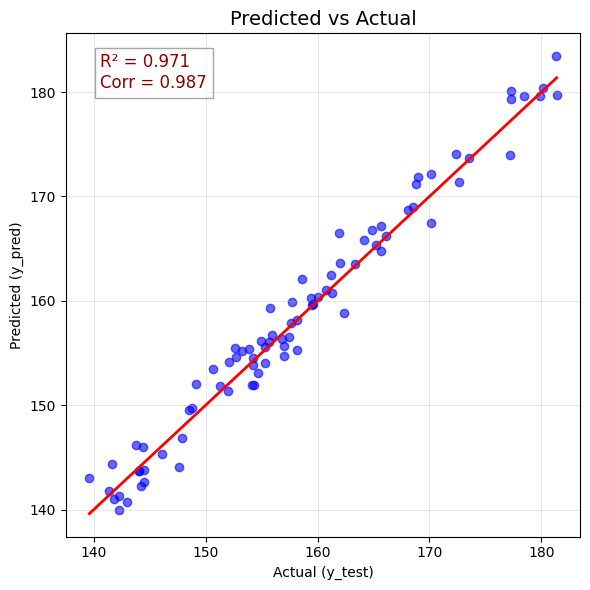

In [260]:
# y_s_test vs y_s_pred

# Correlation coefficient
corr = np.corrcoef(y_s_test, y_s_pred)[0,1] # corelation matrix y_test an y_pred
r2 = r2_score(y_s_test, y_s_pred)

plt.figure(figsize=(6,6))
plt.scatter(y_s_test, y_s_pred, alpha=0.6, color='blue')
plt.plot([y_s_test.min(), y_s_test.max()], [y_s_test.min(), y_s_test.max()], 'r-', linewidth=2)

plt.title("Predicted vs Actual", fontsize=14)
plt.xlabel("Actual (y_test)")
plt.ylabel("Predicted (y_pred)")
plt.grid(alpha=0.3)

# Annotate R² and correlation
plt.text(y_s_test.min()+1, y_s_test.max()-1,
         f"R² = {r2:.3f}\nCorr = {corr:.3f}",
         fontsize=12, color='darkred',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

plt.tight_layout()
plt.show()

In [261]:
test_df['Date'].shape

(78,)

In [262]:
yd_pred.shape

(78,)

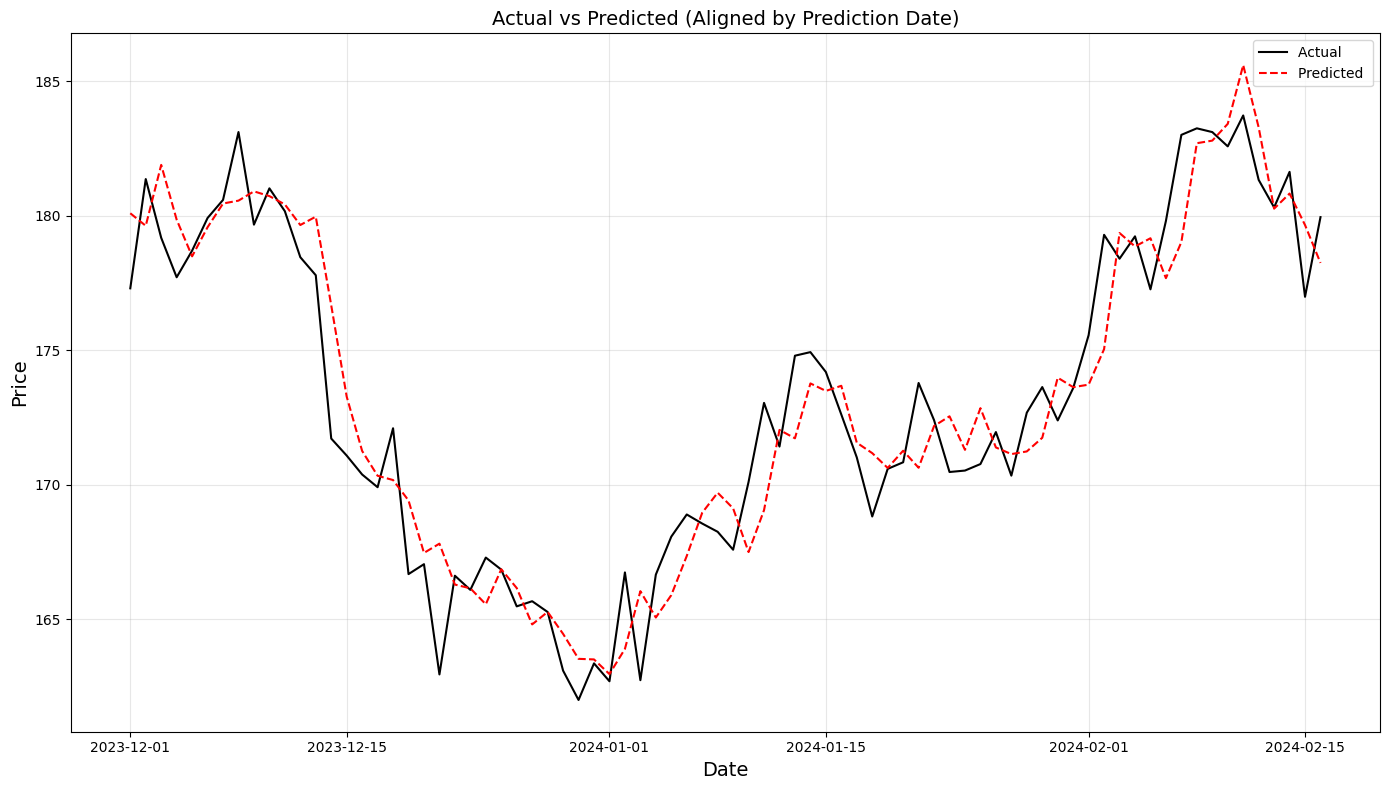

In [263]:
plt.figure(figsize=(14,8))

plt.plot(test_df['Date'], yd_test, label="Actual ", color="black")
plt.plot(test_df['Date'], yd_pred, label="Predicted ", color="red", linestyle="--")

plt.title("Actual vs Predicted (Aligned by Prediction Date)", fontsize=14)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Price", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


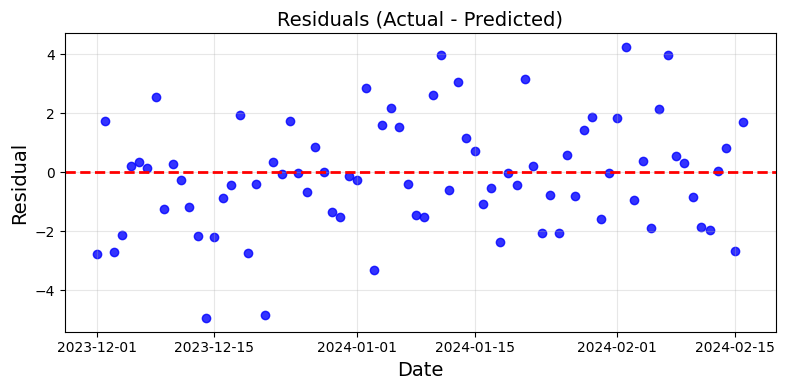

In [264]:
plt.figure(figsize=(8,4))

plt.scatter(test_df['Date'], yd_test-yd_pred, color="b", alpha=0.8)
plt.axhline(0, color = 'r', linestyle="--", linewidth=2)

plt.title("Residuals (Actual - Predicted)", fontsize=14)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Residual", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation of Actual vs Predicted and Residuals**

The model captures the overall trend well, with predicted and actual prices closely overlapping and moving in the same direction. However, the predictions are smoother than the actual series, which leads to underestimation of sudden jumps or drops. The residual plot supports this, showing small, unbiased errors around zero with a few larger deviations during volatile periods.

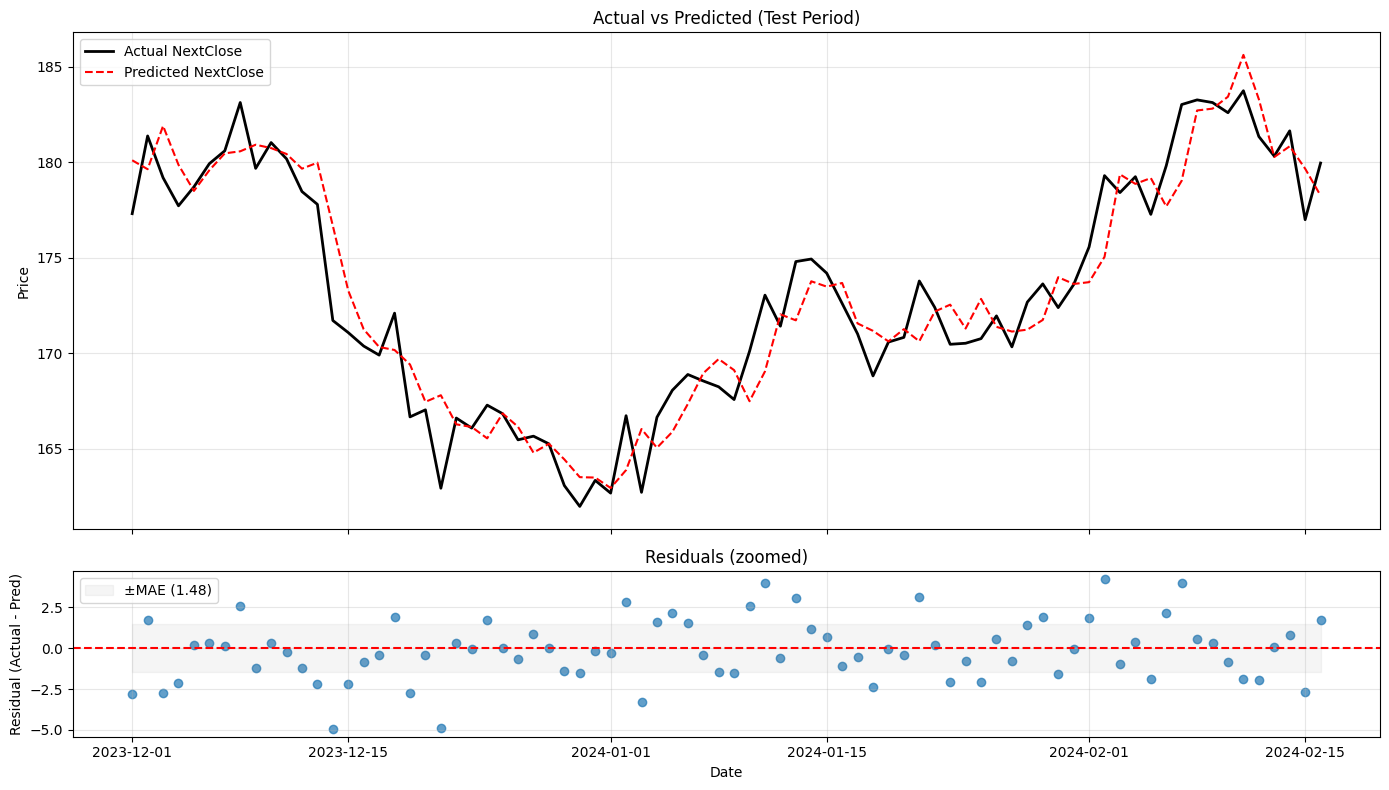

In [266]:
# VISIT LATER

dates = test_df['Date']
actual = yd_test
pred = yd_pred

residuals = actual - pred

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8), sharex=True,
                               gridspec_kw={"height_ratios":[3,1]})

# Top: Actual vs Predicted (full price view)
ax1.plot(dates, actual, label='Actual NextClose', color='black', linewidth=2)
ax1.plot(dates, pred, label='Predicted NextClose', color='red', linestyle='--')
ax1.set_ylabel("Price")
ax1.set_title("Actual vs Predicted (Test Period)")
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Bottom: Residuals (zoomed)
ax2.scatter(dates, residuals, color='tab:blue', alpha=0.7)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_ylabel("Residual (Actual - Pred)")
ax2.set_xlabel("Date")
ax2.set_title("Residuals (zoomed)")
ax2.grid(alpha=0.3)

# Optional: show a horizontal band for +/- 1*MAE or +/- RMSE to judge error size visually
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
ax2.fill_between(dates, mae, -mae, color='gray', alpha=0.08, label=f'±MAE ({mae:.2f})')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


The actual vs predicted chart shows that the model follows price movements very closely, with the two lines almost overlapping. On the wider price scale (140–185), small day-to-day errors are hardly visible. The residual plot zooms into these errors and shows they are mostly within ±3, scattered evenly around zero. This confirms that the model captures the trend well, with small, unbiased prediction errors and only occasional larger misses.

## **Random Forest**

In [267]:
df_new = pd.read_csv('Extended_Stock_Price_Dataset.csv')

In [268]:
df_new.head()

,Date,Open,High,Low,Close,Volume
0,2023-01-02,150.0,152.0,149.5,151.0,1000000
1,2023-01-03,152.3,153.5,151.0,152.0,1100000
2,2023-01-04,151.5,152.0,150.0,151.8,1050000
3,2023-01-05,153.0,154.5,152.0,154.0,1200000
4,2023-01-06,155.0,156.0,154.0,155.5,1150000


In [269]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    410 non-null    object 
 1   Open    410 non-null    float64
 2   High    410 non-null    float64
 3   Low     410 non-null    float64
 4   Close   410 non-null    float64
 5   Volume  410 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 19.3+ KB


In [270]:
df_new['Date'] = pd.to_datetime(df_new['Date'])
df_new = df_new.sort_values(by='Date')

In [271]:
df_new['NextClose'] = df_new['Close'].shift(-1)
df_new.dropna(subset=['NextClose'], inplace=True)

In [272]:
df_new.tail()

,Date,Open,High,Low,Close,Volume,NextClose
404,2024-02-12,183.403310,182.185400,185.611327,183.733346,1406519,181.337925
405,2024-02-13,180.334032,180.401726,183.278017,181.337925,1446397,180.314253
406,2024-02-14,180.858933,179.421794,180.662031,180.314253,1433233,181.635780
407,2024-02-15,179.791203,180.107082,185.009054,181.635780,1405502,176.989789
408,2024-02-16,178.202980,176.707067,176.059321,176.989789,1397405,179.951904


In [273]:
X_r = df_new.drop(columns = ['NextClose', 'Date'], axis = 1)
y_r = df_new['NextClose']

In [274]:
X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(X_r, y_r, test_size=0.2, random_state=42, shuffle=True)

In [275]:
rf = RandomForestRegressor(
    n_estimators=100,      # number of trees
    max_depth=None,        # let trees grow fully (can tune later)
    random_state=42
)

In [276]:
rf.fit(X_r_train, y_r_train)

RandomForestRegressor(random_state=42)

In [277]:
y_r_pred = rf.predict(X_r_test)

In [ ]:
print("MAE:", mean_absolute_error(y_r_test, y_r_pred))
print("Test R² Score:", r2_score(y_r_test, y_r_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_r_test, y_r_pred)))
mape = np.mean(np.abs((y_r_test - y_r_pred) / y_r_test)) * 100
print("MAPE: {:.2f}%".format(mape))

On this dataset, Linear Regression slightly outperforms Random Forest, achieving higher R² (0.97 vs 0.96) and lower RMSE (1.83 vs 2.05). This indicates the underlying relationship between features and the target is primarily linear. However, Random Forest still performs well and provides valuable feature importance insights.

Since Linear Regression already achieves a very high R² score of 0.97, the room for improvement is very limited. In such cases, trying more complex models like Random Forest or performing hyperparameter tuning is unlikely to bring significant gains. Complex models are most beneficial when the baseline linear model performs poorly (e.g., R² ≈ 0.5 or lower). For this dataset, Linear Regression is not only simpler and more interpretable but also optimal in performance.

| Criteria             | Linear Regression                                                 | Random Forest Regressor                                           |
| -------------------- | ----------------------------------------------------------------- | ----------------------------------------------------------------- |
| **Test R² Score**    | **0.9713** (slightly higher)                                      | 0.9641                                                            |
| **Test RMSE**        | **1.83** (lower error)                                            | 2.05                                                              |
| **Interpretability** | Very high (coefficients directly show feature impact)             | Lower (black-box, only feature importance available)              |
| **Computation**      | Very fast, minimal resources                                      | Slower (multiple trees), heavier on system                        |
| **Scalability**      | Easy, works well on small/medium data                             | Handles large, complex data but tuning required                   |
| **When to prefer**   | When relationships are mostly linear and interpretability matters | When non-linear patterns exist or linear regression underperforms |


Linear Regression already achieves a very strong R² (0.97) and low RMSE (1.83), leaving very little room for improvement. Random Forest, while powerful, does not outperform Linear Regression on this dataset. Since the data has largely linear relationships, Linear Regression is chosen as the final model for its simplicity, speed, and interpretability.

RMSE of 1.83 indicates that, on average, predictions deviate by less than ₹2 from actual stock prices. Given the price range (₹150–185), this corresponds to ~5% error, which is very low and indicates strong predictive accuracy.

## **Check Feature Importances**

In [286]:
feat_importances = pd.Series(rf.feature_importances_, index=[['Open', 'High', 'Low', 'Close', 'Volume']]).sort_values(ascending=False)
print("Feature Importances (Random Forest - Basic Features):")
print(feat_importances)

Feature Importances (Random Forest - Basic Features):
Open      0.743411
Close     0.233318
High      0.010424
Low       0.007338
Volume    0.005508
dtype: float64


In [290]:
corr_matrix = df_new[['NextClose','Open','High','Low','Close']].corr()
print(corr_matrix)

           NextClose      Open      High       Low     Close
NextClose   1.000000  0.985902  0.971950  0.967290  0.982296
Open        0.985902  1.000000  0.983669  0.982924  0.996058
High        0.971950  0.983669  1.000000  0.968021  0.991087
Low         0.967290  0.982924  0.968021  1.000000  0.990877
Close       0.982296  0.996058  0.991087  0.990877  1.000000


In [295]:
#corr_matrix = df_new[['NextClose','Open','High','Low','Close']].corr()
#or
#corr_matrix = np.corrcoef(df_new[['NextClose','Open','High','Low','Close']].T)
#or
corr_matrix = np.corrcoef(df_new[['NextClose','Open','High','Low','Close']], rowvar=False)
print(corr_matrix)

[[1.         0.98590185 0.97194989 0.9672898  0.98229588]
 [0.98590185 1.         0.98366884 0.98292357 0.99605841]
 [0.97194989 0.98366884 1.         0.96802059 0.99108659]
 [0.9672898  0.98292357 0.96802059 1.         0.99087678]
 [0.98229588 0.99605841 0.99108659 0.99087678 1.        ]]


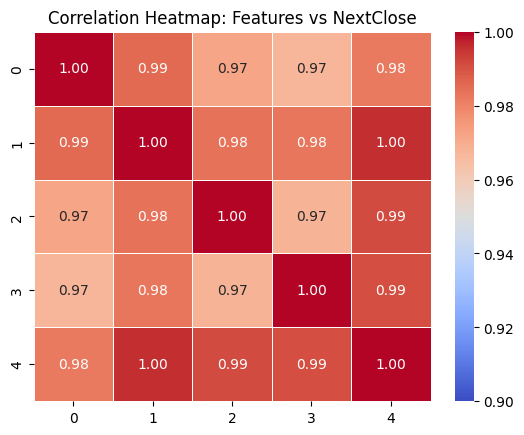

In [296]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=0.90, vmax=1.00)
#sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, center=0)
plt.title("Correlation Heatmap: Features vs NextClose")
plt.show()

The heatmap shows that NextClose is strongly related to both Open and Close, and all the price features are highly related to each other. Linear Regression works well here because it can use these strong linear links. Random Forest, on the other hand, usually picks one feature when many are very similar. In this case, it gave more weight to Open and almost ignored Close, even though both were equally useful. That’s why Random Forest did not perform as well as Linear Regression.

## **Feature Engineering** - Random Forest & Linear Regression

Feature engineering is the process of creating new input variables from existing data to help the model learn better. In this project, we generate lag features (previous day prices), rolling statistics (short-term averages and volatility), and percentage changes to give the model a sense of market history and trends. These engineered features allow Random Forest to capture patterns that are not visible from just the raw Close price.

In [ ]:
df_new.info()

In [ ]:
df_new.head()

In [ ]:
# In this experiment, we focus only on the 'Close' price as the primary feature
# because it is the strongest and most commonly used indicator in stock forecasting.
# Other features like [Open, High, Low, and Volume] may provide additional signals,
# but 'Close' captures the consolidated daily sentiment and keeps the initial model
# simple and interpretable. Future work can extend the model by incorporating
# these additional features.

In [ ]:
df_current = df_new.copy()
print("rows, cols:", df_current.shape)
print(df_current.columns.tolist())
#display(df_current[['Date','Close','NextClose']].head(6))

In [ ]:
# Create basic lag features from Close
df_current = df_current.sort_values('Date').reset_index(drop=True)

df_current['lag1'] = df_current['Close'].shift(1)
df_current['lag2'] = df_current['Close'].shift(2)

display(df_current[['Date','Close','lag1','lag2','NextClose']].head(8))


In [ ]:
# Rolling statistics (3-day window)
df_current['roll_mean_3'] = df_current['Close'].shift(1).rolling(window=3, min_periods=1).mean()
df_current['roll_std_3']  = df_current['Close'].shift(1).rolling(window=3, min_periods=1).std().fillna(0)

display(df_current[['Date','Close','lag1','lag2','roll_mean_3','roll_std_3','NextClose']].head(8))


In [ ]:
# Add percent change feature
df_current['pct_1'] = df_current['Close'].pct_change(periods=1)

display(df_current[['Date','Close','lag1','lag2','roll_mean_3','roll_std_3','pct_1','NextClose']].head(8))
#df_current.head(8)


In [ ]:
# We did not drop columns like Open, High, Low, and Volume at the start,
# because they do not interfere with modeling when we explicitly define our
# features list. Keeping them provides flexibility to experiment later
# (e.g., adding Volume as a feature). In this experiment, we restrict
# ourselves to Close-based features, but the other columns are preserved
# for possible future use and analysis.

In [ ]:
# Clean dataset & prepare features
features = ['lag1','lag2','roll_mean_3','roll_std_3','pct_1']

df_ready = df_current.dropna(subset=['NextClose'] + features).reset_index(drop=True)

print("Rows before:", len(df_current), "after dropping NaNs:", len(df_ready))
print("Feature columns:", features)

# quick peek
display(df_ready[['Date','Close'] + features + ['NextClose']].head(6))

In [ ]:
# Train/Test split (time-aware, no shuffle)
split_frac = 0.8
n = len(df_ready)
train_n = int(n*split_frac)

train_df = df_ready.iloc[:train_n].copy()
test_df = df_ready.iloc[train_n:].copy()

X_train = train_df[features].values
y_train = train_df['NextClose'].values

X_test = test_df[features].values
y_test = test_df['NextClose'].values

In [ ]:
# Baseline (naive forecast)
baseline_pred = test_df['Close'].values

mae_baseline = mean_absolute_error(y_test, baseline_pred)
rmse_baseline = math.sqrt(mean_squared_error(y_test, baseline_pred))
mape_baseline = np.mean(np.abs((y_test - baseline_pred) / y_test)) * 100

print("Baseline -> MAE: {:.4f}, RMSE: {:.4f}, MAPE: {:.2f}%".format(mae_baseline, rmse_baseline, mape_baseline))


In [ ]:
# Linear Regression benchmark
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = math.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100

print("Linear Regression -> MAE: {:.4f}, RMSE: {:.4f}, R2: {:.4f}, MAPE: {:.2f}%"
      .format(mae_lr, rmse_lr, r2_lr, mape_lr))


In [ ]:
# New feature list for Linear Regression
features_lr = ['lag1','lag2']

X_train_lr = train_df[features_lr].values
y_train_lr = train_df['NextClose'].values
X_test_lr  = test_df[features_lr].values
y_test_lr  = test_df['NextClose'].values

# Train Linear Regression
lr_simple = LinearRegression()
lr_simple.fit(X_train_lr, y_train_lr)
y_pred_lr_simple = lr_simple.predict(X_test_lr)

# Evaluate
mae_lr_simple = mean_absolute_error(y_test_lr, y_pred_lr_simple)
rmse_lr_simple = math.sqrt(mean_squared_error(y_test_lr, y_pred_lr_simple))
r2_lr_simple = r2_score(y_test_lr, y_pred_lr_simple)
mape_lr_simple = np.mean(np.abs((y_test_lr - y_pred_lr_simple) / y_test_lr)) * 100

print("LR (Lag1+Lag2 only) -> MAE: {:.4f}, RMSE: {:.4f}, R2: {:.4f}, MAPE: {:.2f}%"
      .format(mae_lr_simple, rmse_lr_simple, r2_lr_simple, mape_lr_simple))


Linear Regression initially appeared very strong when we used random splits with shuffle=True, but this was due to information leakage since the model was indirectly exposed to parts of the future data during training. When we switched to a time-aware split (shuffle=False), the performance became more realistic and stable, reflecting how models behave in real-world forecasting where only past data is available for predicting the future. We also experimented with engineered features such as rolling averages and volatility, but these did not improve Linear Regression because of multicollinearity, as the features were highly correlated with each other. However, such engineered features are more beneficial for tree-based models like Random Forest, which can handle non-linear relationships and redundant information more effectively.

| Split Type               | Shuffle | Features Used       | MAE    | RMSE   | R²     | MAPE  |
| ------------------------ | ------- | ------------------- | ------ | ------ | ------ | ----- |
| Random Split             | True    | Close only          | 1.4850 | 1.8336 | 0.9714 | 0.95% |
| Random Split             | False   | Close only          | 1.4599 | 1.8822 | 0.9048 | 0.84% |
| Time-aware Split (80/20) | False   | Engineered features | 1.6995 | 2.1239 | 0.8788 | 0.98% |


Linear Regression achieved the strongest results when using random splits with shuffle=True, but this was inflated by information leakage. With time-aware splitting, its performance became realistic and slightly weaker. When engineered features such as lags, rolling averages, and percent change were added, the model’s performance degraded further because Linear Regression cannot effectively leverage correlated or non-linear features. These engineered features are better suited for non-linear models such as Random Forest.

In [ ]:
# Random Forest with engineered features
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = math.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print("Random Forest -> MAE: {:.4f}, RMSE: {:.4f}, R2: {:.4f}, MAPE: {:.2f}%"
      .format(mae_rf, rmse_rf, r2_rf, mape_rf))


In our initial experiments, Random Forest underperformed compared to both the baseline and Linear Regression. This is likely due to the small dataset size and limited feature set. Tree-based models typically require richer features (longer lags, rolling windows, volatility indicators) to capture patterns effectively. Future work should extend the feature engineering to give Random Forest more context

| Model                          | MAE    | RMSE   | R²     | MAPE (%) |
| ------------------------------ | ------ | ------ | ------ | -------- |
| Baseline (Naive)               | 1.7408 | 2.1943 | –      | 1.00     |
| Linear Regression (Engineered) | 1.6995 | 2.1239 | 0.8788 | 0.98     |
| Random Forest (Engineered)     | 3.3753 | 4.1657 | 0.5319 | 1.91     |


This table makes it clear that while Linear Regression is performing slightly better than the naive baseline, Random Forest underperforms with the current feature set. Feature importance analysis confirmed that only lag1 and short-term rolling averages were useful, while other engineered features did not add value.

| Model             | Split Type       | Shuffle | Features Used       | MAE    | RMSE   | R²     | MAPE  |
| ----------------- | ---------------- | ------- | ------------------- | ------ | ------ | ------ | ----- |
| Baseline (Naive)  | Date cutoff      | –       | Close only          | 1.7493 | 2.2029 | –      | 1.01% |
| Linear Regression | Date cutoff      | –       | Close only          | 1.4800 | 1.8953 | 0.9027 | 0.86% |
| Linear Regression | Random split     | True    | Close only          | 1.4850 | 1.8336 | 0.9714 | 0.95% |
| Linear Regression | Random split     | False   | Close only          | 1.4599 | 1.8822 | 0.9048 | 0.84% |
| Random Forest     | Random split     | True    | Close only          | 1.6784 | 2.0514 | 0.9641 | 1.06% |
| Random Forest     | Random split     | False   | Close only          | 3.9474 | 5.0175 | 0.3238 | 2.23% |
| Linear Regression | Time-aware 80/20 | False   | Engineered features | 1.6995 | 2.1239 | 0.8788 | 0.98% |
| Random Forest     | Time-aware 80/20 | False   | Engineered features | 3.3753 | 4.1657 | 0.5319 | 1.91% |


This consolidated table shows the evolution of models across different splits and feature sets. Linear Regression is consistently strong with simple lag information, but suffers when engineered features are added. Random Forest performs well under random splits but underperforms in realistic time-aware scenarios unless provided with richer features and more data.

**Linear Regression consistently outperformed the naive baseline in realistic time-aware splits, making it the most reliable model for this dataset. Random Forest underperformed despite feature engineering, as only lag1 and short-term averages proved useful, indicating that richer features and larger data are needed for tree-based models to add value.**

# ***Target Column Exploration - Linear Regression***

In [ ]:
# R2 Score: 0.9713524998668867
# RMSE: 1.8336053853813223

In [ ]:
print(y.describe()) # y = df['NextClose']

In [ ]:
print("Target Range:", y.min(), "to", y.max())
print("Target Mean:", y.mean())
print("Target Std:", y.std())

In [ ]:
# RMSE as % of Range
rmse_perc_range  = rmse/(y.max() - y.min())
print((round(rmse_perc_range,2)*100),"%")

In [ ]:
# RMSE as % of Mean
rmse_perc_mean  = rmse/(y.mean())
print((round(rmse_perc_mean,2)*100),"%")

On average, the model’s prediction is off by about ₹1.8.
Since the typical stock price is around ₹160, this means predictions are usually within ±1% of the actual value.
In practical terms, if the stock is ₹160, the model will generally predict between ₹158 and ₹162.

In [ ]:
# RMSE as % of std
rmse_perc_std  = rmse/(y.std())
print((round(rmse_perc_std,2)*100),"%")

Error Interpretation:

The model’s Root Mean Squared Error (RMSE) is approximately ₹1.83. To put this into perspective:

Mean-based: Since the average stock price in the dataset is around ₹160, this error represents only about ±1% of the typical stock value. In practical terms, if the stock is priced at ₹160, the model generally predicts within the range of ₹158–₹162.

Range-based: The stock prices in the dataset vary between ₹139 and ₹184, a total range of ~₹44. The model’s error of ₹1.83 is only 4% of this entire movement, indicating that the error is very small compared to the full spread of prices.

Standard Deviation–based: The natural daily variability of stock prices (standard deviation) is ~₹10.9. The model’s error corresponds to only 17% of this volatility, which shows that the model performs well even when compared against the inherent market noise.

Conclusion: The model’s predictions are highly accurate, with deviations that are minimal relative to the stock’s scale, range, and natural variability.

| Model                | Split type   | Shuffle | MAE    | RMSE   | R²     | MAPE  |
| -------------------- | ------------ | ------- | ------ | ------ | ------ | ----- |
| **Baseline (naive)** | Date cutoff  | –       | 1.7493 | 2.2029 | –      | 1.01% |
| Linear Regression    | Date cutoff  | –       | 1.4800 | 1.8953 | 0.9027 | 0.86% |
| Linear Regression    | Random split | True    | 1.4850 | 1.8336 | 0.9714 | 0.95% |
| Linear Regression    | Random split | False   | 1.4599 | 1.8822 | 0.9048 | 0.84% |
| Random Forest        | Random split | True    | 1.6784 | 2.0514 | 0.9641 | 1.06% |
| Random Forest        | Random split | False   | 3.9474 | 5.0175 | 0.3238 | 2.23% |
